# Incremental Model Comparison — Erosion Rate Prediction

Objective: systematically compare models from naive baseline → full-feature LightGBM, all
evaluated on the held-out **test split** from `region_features.parquet`.

| # | Name | Features |
|---|------|----------|
| 0 | Naive mean | global mean of v_train |
| 1 | v_train baseline | v_test = v_train (paper baseline) |
| 2 | OLS – v_train only | linear regression on v_train |
| 3 | Ridge – numeric | v_train + dist_t2 + peak_p99 + days_above_p90 + spans |
| 4 | Ridge – + categorical | + river_enc + is_nvo + vegetation_enc + soil_enc |
| 5 | LightGBM | all features, raw encoded cats |

Each model reports **RMSE**, **MAE**, **R²** on train and test. A final summary
bar chart and SHAP analysis are included.


In [1]:
import sys
from pathlib import Path

# Walk up from cwd to find the backend root (where src/ lives).
# Works whether the kernel cwd is backend/ or backend/notebooks/04_model/.
_cwd = Path.cwd()
for _p in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_p / "src").is_dir():
        sys.path.insert(0, str(_p))
        break

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import shap

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
SEED = 42


In [2]:
import src.paths as PATHS

FEAT_PATH = PATHS.DATA_DIR / "02_processed" / "erosion" / "region_features.parquet"
feat = pd.read_parquet(FEAT_PATH)

train = feat[feat["split"] == "train"].copy()
test  = feat[feat["split"] == "test"].copy()

TARGET = "v_test"

print(f"Train: {len(train):,}  |  Test: {len(test):,}")
print(f"Target – train  mean={train[TARGET].mean():.3f}  std={train[TARGET].std():.3f}")
print(f"Target – test   mean={test[TARGET].mean():.3f}  std={test[TARGET].std():.3f}")
feat.head(3)


Train: 7,521  |  Test: 1,881
Target – train  mean=0.535  std=4.348
Target – test   mean=0.683  std=4.321


,v_train,v_test,dist_t1,dist_t2,dist_t3,train_span_yr,test_span_yr,is_nvo,river,river_enc,...,vegetation_class_enc,land_use,land_use_enc,soil_group,soil_group_enc,nearest_station,peak_p99,days_above_p90,split,cluster
location_id,,,,,,,,,,,,,,,,,,,,,
ijssel1_l_0010_0020,0.150221,0.166912,155.478645,156.229750,156.730486,5,3,False,ijssel1,5,...,1,None,-1,River clay,0,westervoort.ijsselkop,643.666433,21.5,train,ijssel1
ijssel1_l_0020_0030,0.016667,-0.055556,168.083333,168.166667,168.000000,5,3,False,ijssel1,5,...,1,None,-1,River clay,0,westervoort.ijsselkop,643.666433,21.5,test,ijssel1
ijssel1_l_0050_0056,-0.083333,-0.555556,48.916667,48.500000,46.833333,5,3,False,ijssel1,5,...,1,None,-1,River clay,0,westervoort.ijsselkop,643.666433,21.5,train,ijssel1


In [3]:
RESULTS = {}   # keyed by model name

TAIL_THRESHOLD = 2.0  # m/yr — operationally critical regions

def evaluate(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Compute metrics and store in RESULTS dict. MAE primary, RMSE secondary, tail MAE for v_test > 2 m/yr."""
    y_true = np.asarray(y_test_true)
    y_pred = np.asarray(y_test_pred)
    mask = y_true > TAIL_THRESHOLD
    tail_n = int(mask.sum())
    tail_mae = mean_absolute_error(y_true[mask], y_pred[mask]) if tail_n > 0 else np.nan

    row = dict(
        train_rmse=root_mean_squared_error(y_train_true, y_train_pred),
        train_mae =mean_absolute_error(y_train_true, y_train_pred),
        train_r2  =r2_score(y_train_true, y_train_pred),
        test_rmse =root_mean_squared_error(y_test_true, y_test_pred),
        test_mae  =mean_absolute_error(y_test_true, y_test_pred),
        test_r2   =r2_score(y_test_true, y_test_pred),
        test_tail_mae=tail_mae,
        test_tail_n  =tail_n,
    )
    RESULTS[name] = row
    print(f"  {'metric':>14}    train       test")
    print(f"  {'MAE (prim)':>14}    {row['train_mae']:.4f}    {row['test_mae']:.4f}")
    print(f"  {'RMSE':>14}    {row['train_rmse']:.4f}    {row['test_rmse']:.4f}")
    print(f"  {'MAE tail>2':>14}    {'—':>6}    {row['test_tail_mae']:.4f}  (n={tail_n})")
    print(f"  {'R²':>14}    {row['train_r2']:.4f}    {row['test_r2']:.4f}")
    return row


def scatter_pred(y_true, y_pred, title, ax=None):
    """Scatter of predicted vs actual with 45-degree line."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    lo = min(float(y_true.min()), float(y_pred.min())) - 0.05
    hi = max(float(y_true.max()), float(y_pred.max())) + 0.05
    ax.scatter(y_true, y_pred, s=6, alpha=0.25, color="#1f77b4")
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Actual v_test  (m/yr)"); ax.set_ylabel("Predicted  (m/yr)")
    ax.set_title(title, fontsize=10)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ax.annotate(f"RMSE={rmse:.3f}\nR²={r2:.3f}", xy=(0.05, 0.88),
                xycoords="axes fraction", fontsize=8, va="top")
    if own_fig:
        plt.tight_layout(); plt.show()


## Model 0 – Naive mean baseline
Predicts the training-set mean of `v_test` for every observation. Sets the floor.

Model 0 – Naive mean
      metric    train       test
        RMSE    4.3473    4.3219
         MAE    1.5211    1.5464
          R²    0.0000    -0.0012


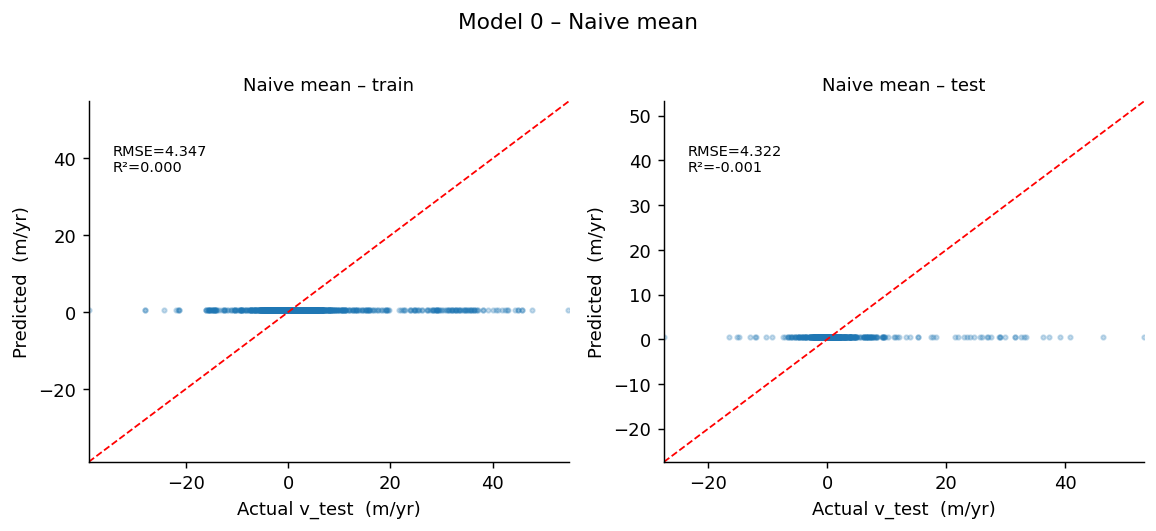

In [4]:
global_mean = train[TARGET].mean()
y_train_pred_0 = np.full(len(train), global_mean)
y_test_pred_0  = np.full(len(test),  global_mean)

print("Model 0 – Naive mean")
evaluate("0 – Naive mean", train[TARGET], y_train_pred_0, test[TARGET], y_test_pred_0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, y_train_pred_0, "Naive mean – train", axes[0])
scatter_pred(test[TARGET].values,  y_test_pred_0,  "Naive mean – test",  axes[1])
plt.suptitle("Model 0 – Naive mean", y=1.01)
plt.tight_layout(); plt.show()


## Model 1 – v_train baseline  *(paper baseline)*
Sets `v_test = v_train`. Equivalent to `BaselineErosionModel` translated to the
cross-sectional feature table: assume future erosion rate = historical rate.

Model 1 – v_train baseline
      metric    train       test
        RMSE    6.4179    6.8068
         MAE    1.9931    2.1436
          R²    -1.1795    -1.4833


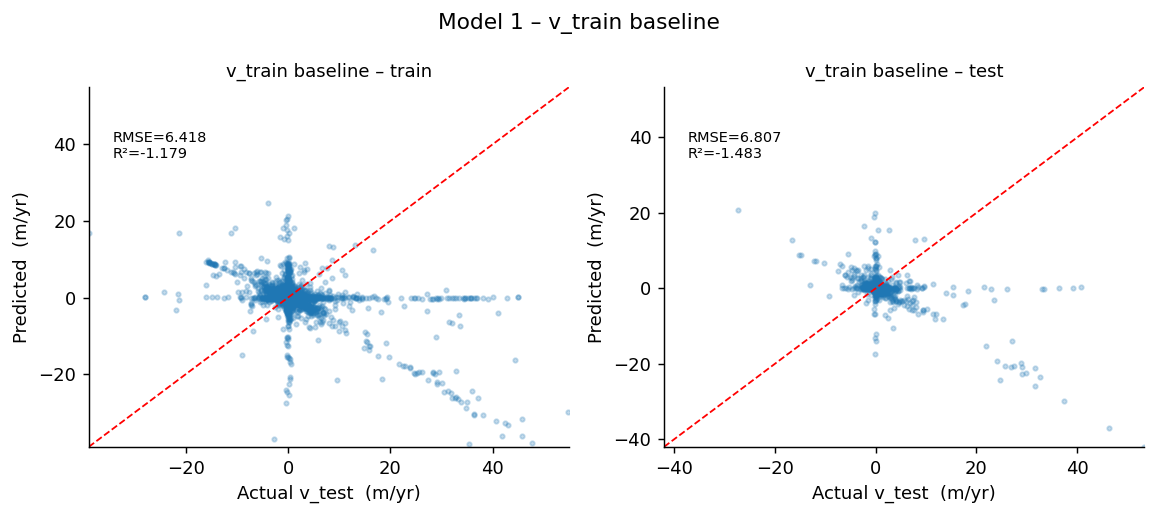

In [5]:
print("Model 1 – v_train baseline")
evaluate("1 – v_train baseline",
         train[TARGET], train["v_train"],
         test[TARGET],  test["v_train"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, train["v_train"].values, "v_train baseline – train", axes[0])
scatter_pred(test[TARGET].values,  test["v_train"].values,  "v_train baseline – test",  axes[1])
plt.suptitle("Model 1 – v_train baseline")
plt.tight_layout(); plt.show()


## Model 2 – OLS, v_train only
Fits a simple linear regression on `v_train`. Tests whether a linear correction
(slope ≠ 1, intercept ≠ 0) over the raw mean-reversion baseline is beneficial.

Model 2 – OLS v_train
  coefficient: -0.8288   intercept: 0.5102
      metric    train       test
        RMSE    3.6359    3.2711
         MAE    1.4205    1.3701
          R²    0.3005    0.4265


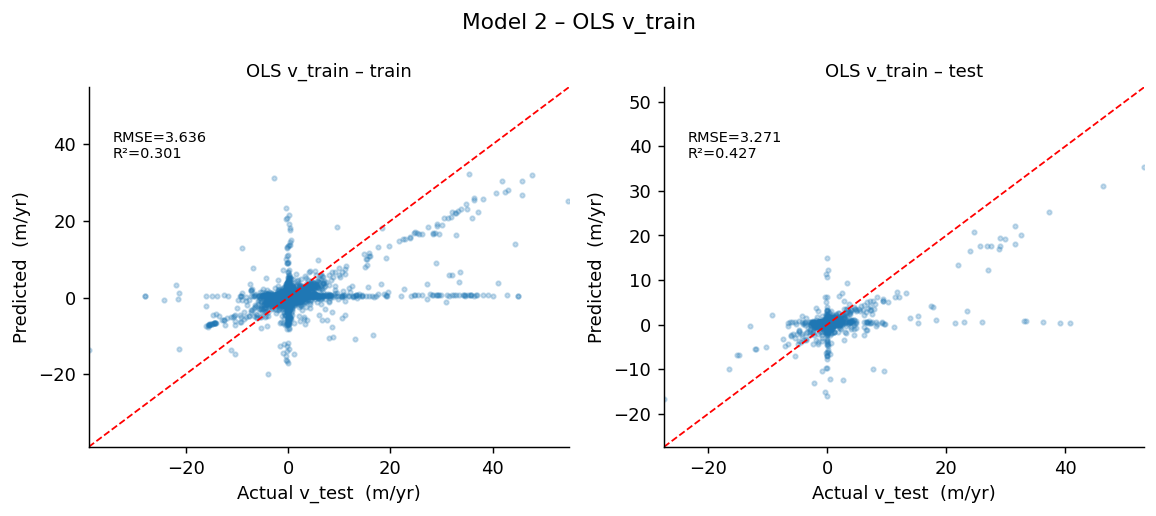

In [6]:
FEATS_2 = ["v_train"]

ols_vt = LinearRegression()
ols_vt.fit(train[FEATS_2].values, train[TARGET])

print("Model 2 – OLS v_train")
print(f"  coefficient: {ols_vt.coef_[0]:.4f}   intercept: {ols_vt.intercept_:.4f}")
evaluate("2 – OLS v_train",
         train[TARGET], ols_vt.predict(train[FEATS_2].values),
         test[TARGET],  ols_vt.predict(test[FEATS_2].values))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, ols_vt.predict(train[FEATS_2].values), "OLS v_train – train", axes[0])
scatter_pred(test[TARGET].values,  ols_vt.predict(test[FEATS_2].values),  "OLS v_train – test",  axes[1])
plt.suptitle("Model 2 – OLS v_train")
plt.tight_layout(); plt.show()


## Model 3 – Ridge, numeric features only
Adds absolute bank position (`dist_t2`), discharge statistics (`peak_p99`,
`days_above_p90`) and time-span controls (`train_span_yr`, `test_span_yr`).
Features are standardised; Ridge regularisation α = 1.

Model 3 – Ridge numeric
                 v_train: -2.3204
                 dist_t2: -0.4304
                peak_p99: +0.2765
          days_above_p90: +0.3302
           train_span_yr: +0.0000
            test_span_yr: +0.5520
      metric    train       test
        RMSE    3.6098    3.2408
         MAE    1.4572    1.3999
          R²    0.3105    0.4371


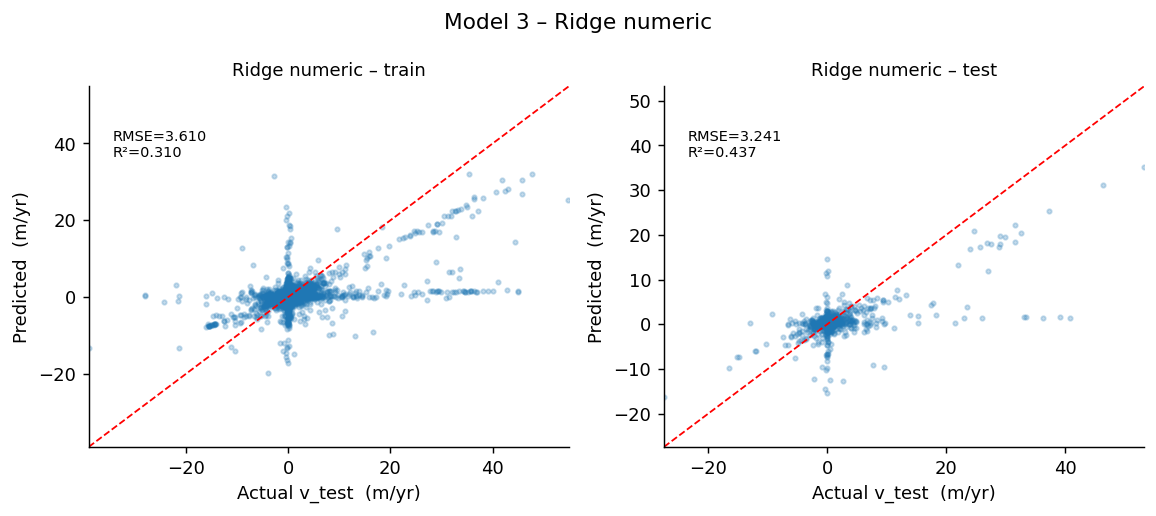

In [7]:
FEATS_3 = ["v_train", "dist_t2", "peak_p99", "days_above_p90",
           "train_span_yr", "test_span_yr"]

ridge_num = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_num.fit(train[FEATS_3].values, train[TARGET])

print("Model 3 – Ridge numeric")
for f, c in zip(FEATS_3, ridge_num.named_steps["ridge"].coef_):
    print(f"  {f:>22s}: {c:+.4f}")

evaluate("3 – Ridge numeric",
         train[TARGET], ridge_num.predict(train[FEATS_3].values),
         test[TARGET],  ridge_num.predict(test[FEATS_3].values))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, ridge_num.predict(train[FEATS_3].values), "Ridge numeric – train", axes[0])
scatter_pred(test[TARGET].values,  ridge_num.predict(test[FEATS_3].values),  "Ridge numeric – test",  axes[1])
plt.suptitle("Model 3 – Ridge numeric")
plt.tight_layout(); plt.show()


## Model 4 – Ridge, numeric + categorical features
Adds `is_nvo`, `river_enc`, `vegetation_class_enc`, `soil_group_enc`.
Missing/unknown categories are encoded as -1 (a distinct ordinal level).

Model 4 – Ridge + categorical
                     v_train: -2.2930
                     dist_t2: -0.5758
                    peak_p99: +0.0667
              days_above_p90: -0.0770
               train_span_yr: +0.0000
                test_span_yr: +0.7293
                      is_nvo: +0.0497
                   river_enc: -0.4060
        vegetation_class_enc: +0.0009
              soil_group_enc: +0.1093
      metric    train       test
        RMSE    3.6009    3.2390
         MAE    1.4834    1.4246
          R²    0.3139    0.4377


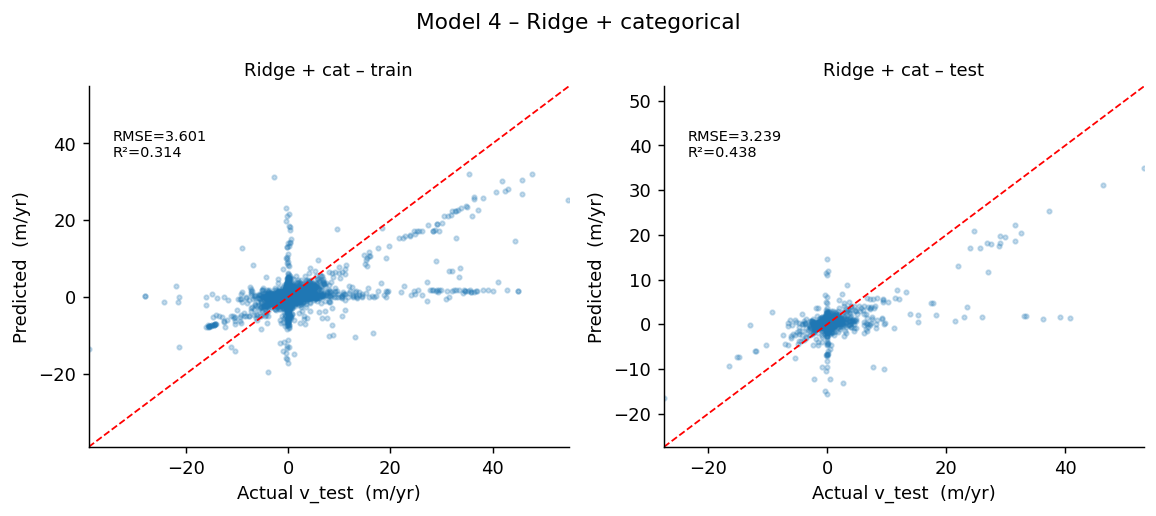

In [8]:
FEATS_4 = ["v_train", "dist_t2", "peak_p99", "days_above_p90",
           "train_span_yr", "test_span_yr",
           "is_nvo", "river_enc", "vegetation_class_enc", "soil_group_enc"]


def prep_cats(df, cols):
    out = df[cols].copy()
    if "is_nvo" in out.columns:
        out["is_nvo"] = out["is_nvo"].astype(int)
    return out.astype(float).values


ridge_cat = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_cat.fit(prep_cats(train, FEATS_4), train[TARGET])

print("Model 4 – Ridge + categorical")
for f, c in zip(FEATS_4, ridge_cat.named_steps["ridge"].coef_):
    print(f"  {f:>26s}: {c:+.4f}")

evaluate("4 – Ridge + categorical",
         train[TARGET], ridge_cat.predict(prep_cats(train, FEATS_4)),
         test[TARGET],  ridge_cat.predict(prep_cats(test,  FEATS_4)))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, ridge_cat.predict(prep_cats(train, FEATS_4)), "Ridge + cat – train", axes[0])
scatter_pred(test[TARGET].values,  ridge_cat.predict(prep_cats(test,  FEATS_4)), "Ridge + cat – test",  axes[1])
plt.suptitle("Model 4 – Ridge + categorical")
plt.tight_layout(); plt.show()


## Model 5 – LightGBM, all features
Tree-based model that can exploit non-linear relationships and feature interactions.
Categorical columns are passed as their integer-encoded versions (including -1 for
unknown). LightGBM handles missing-value-like indicators natively.

Hyperparameters are set conservatively to avoid overfit on this dataset size.

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN


Model 5 – LightGBM
      metric    train       test
        RMSE    1.9915    2.5965
         MAE    0.9148    1.2139
          R²    0.7901    0.6386


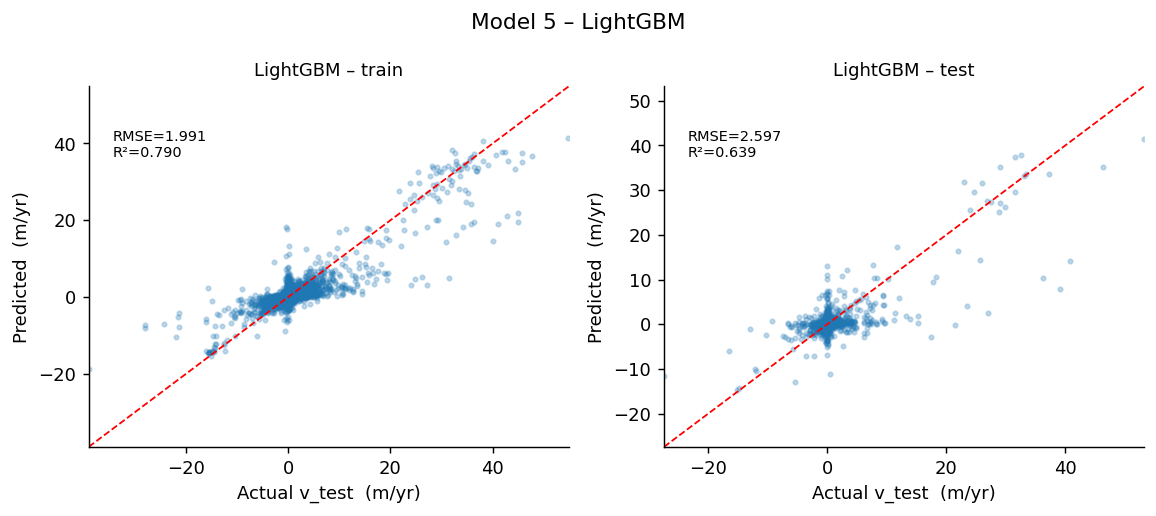

In [9]:
FEATS_LGB = ["v_train", "dist_t2", "peak_p99", "days_above_p90",
             "train_span_yr", "test_span_yr",
             "is_nvo", "river_enc", "vegetation_class_enc", "soil_group_enc"]
CAT_FEATS = ["river_enc", "vegetation_class_enc", "soil_group_enc"]


def prep_lgb(df, cols):
    out = df[cols].copy()
    if "is_nvo" in out.columns:
        out["is_nvo"] = out["is_nvo"].astype(int)
    return out.astype(float)


X_tr_lgb = prep_lgb(train, FEATS_LGB)
X_te_lgb = prep_lgb(test,  FEATS_LGB)

dtrain = lgb.Dataset(X_tr_lgb, label=train[TARGET],
                     categorical_feature=CAT_FEATS, free_raw_data=False)

params = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    verbose=-1,
    seed=SEED,
)

lgb_model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,
    callbacks=[lgb.log_evaluation(period=0)],
)

y_tr_lgb = lgb_model.predict(X_tr_lgb)
y_te_lgb = lgb_model.predict(X_te_lgb)

print("Model 5 – LightGBM")
evaluate("5 – LightGBM", train[TARGET], y_tr_lgb, test[TARGET], y_te_lgb)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, y_tr_lgb, "LightGBM – train", axes[0])
scatter_pred(test[TARGET].values,  y_te_lgb, "LightGBM – test",  axes[1])
plt.suptitle("Model 5 – LightGBM")
plt.tight_layout(); plt.show()


## Summary — all models

| Metriek | Wat het meet | Gebruik |
| --- | --- | --- |
| **MAE** | Gemiddelde nauwkeurigheid over alle regio's | Primair — "hoe goed is het model overall?" |
| **RMSE** | Gevoeligheid voor grote fouten / staart | Secundair — "missen we de gevaarlijke gevallen?" |
| **MAE tail>2** | MAE op v_test > 2 m/yr alleen | Meest operationeel relevant — "hoe goed voorspellen we de kritieke regio's?" |

,test_rmse,test_mae,test_r2,train_rmse,train_r2
0 – Naive mean,4.3219,1.5464,-0.0012,4.3473,0.0000
1 – v_train baseline,6.8068,2.1436,-1.4833,6.4179,-1.1795
2 – OLS v_train,3.2711,1.3701,0.4265,3.6359,0.3005
3 – Ridge numeric,3.2408,1.3999,0.4371,3.6098,0.3105
4 – Ridge + categorical,3.2390,1.4246,0.4377,3.6009,0.3139
5 – LightGBM,2.5965,1.2139,0.6386,1.9915,0.7901


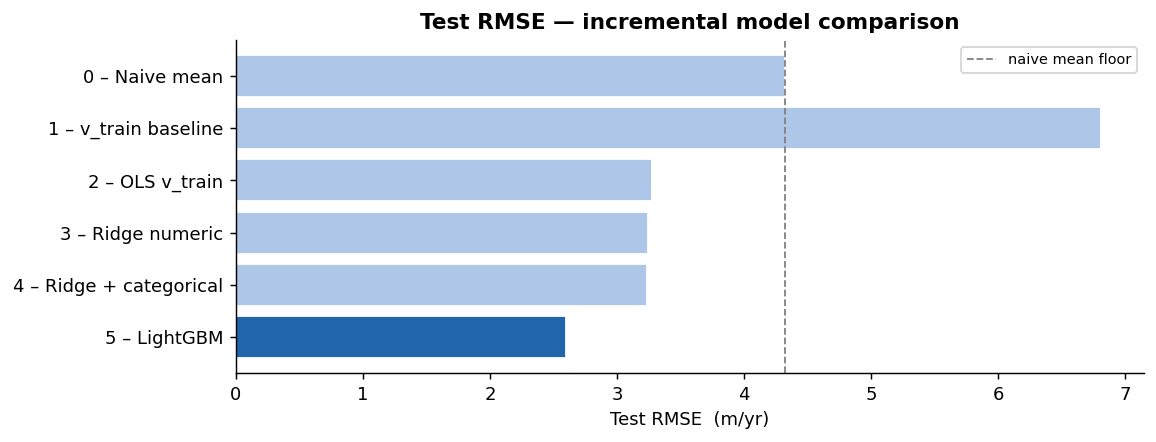

In [10]:
summary = pd.DataFrame(RESULTS).T
# Primary: MAE, secondary: RMSE, operational: tail MAE
summary = summary[["test_mae", "test_rmse", "test_tail_mae", "test_r2", "train_mae", "train_rmse", "train_r2"]]

display(summary.round(4).style
        .background_gradient(subset=["test_mae"], cmap="RdYlGn_r")
        .background_gradient(subset=["test_tail_mae"], cmap="RdYlGn_r")
        .background_gradient(subset=["test_r2"], cmap="RdYlGn")
        .format("{:.4f}"))

# Bar chart — primary metric: test MAE
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["#2166ac" if "LightGBM" in n else "#aec6e8" for n in summary.index]
ax.barh(summary.index, summary["test_mae"], color=colors, edgecolor="white")
ax.axvline(summary.loc["0 – Naive mean", "test_mae"], color="grey",
           linestyle="--", lw=1, label="naive mean floor")
ax.set_xlabel("Test MAE  (m/yr) — primair metriek")
ax.set_title("Test MAE — incremental model comparison", fontweight="bold")
ax.invert_yaxis()
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Feature importance — LightGBM

**Left**: built-in gain importance.  
**Right**: SHAP beeswarm on the test set — how much each feature shifts the prediction.

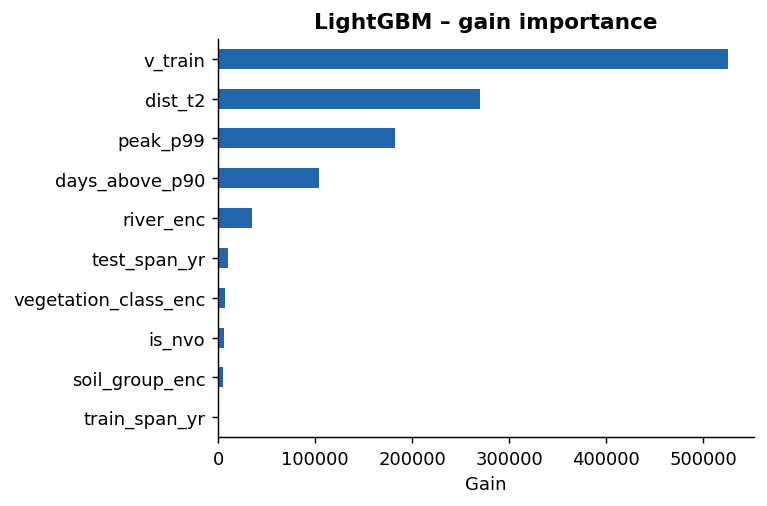

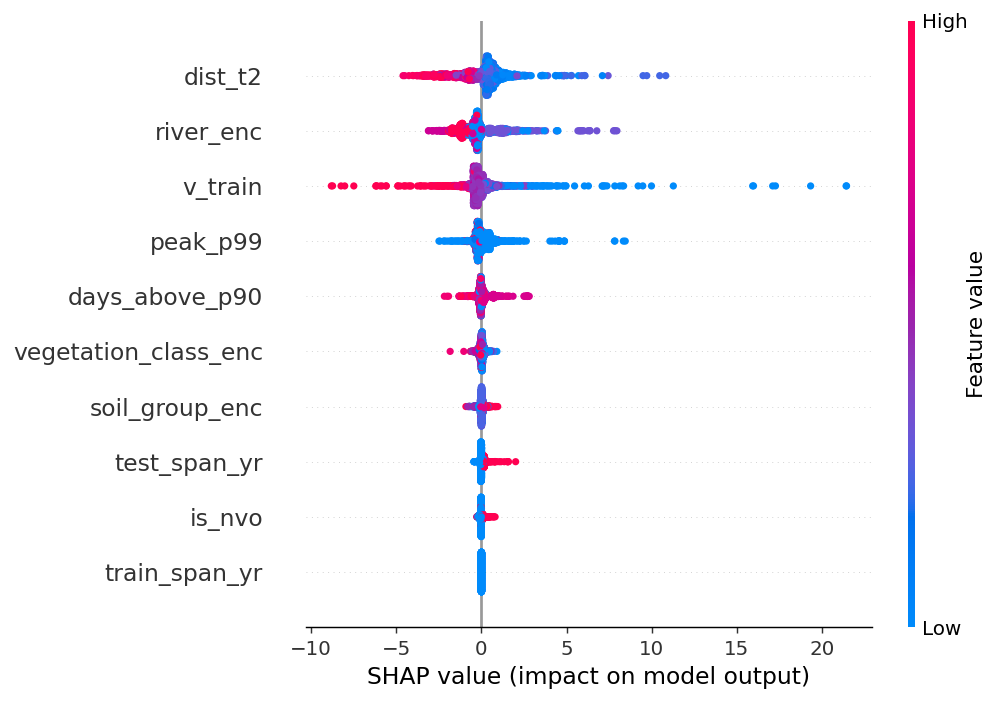

In [11]:
fi = pd.Series(lgb_model.feature_importance(importance_type="gain"),
               index=FEATS_LGB).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
fi.plot.barh(ax=ax, color="#2166ac")
ax.set_xlabel("Gain")
ax.set_title("LightGBM – gain importance", fontweight="bold")
plt.tight_layout(); plt.show()

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_te_lgb)
shap.summary_plot(shap_values, X_te_lgb, feature_names=FEATS_LGB, show=True)


## Ridge coefficient plot — Model 4
Standardised coefficients reveal relative effect size.

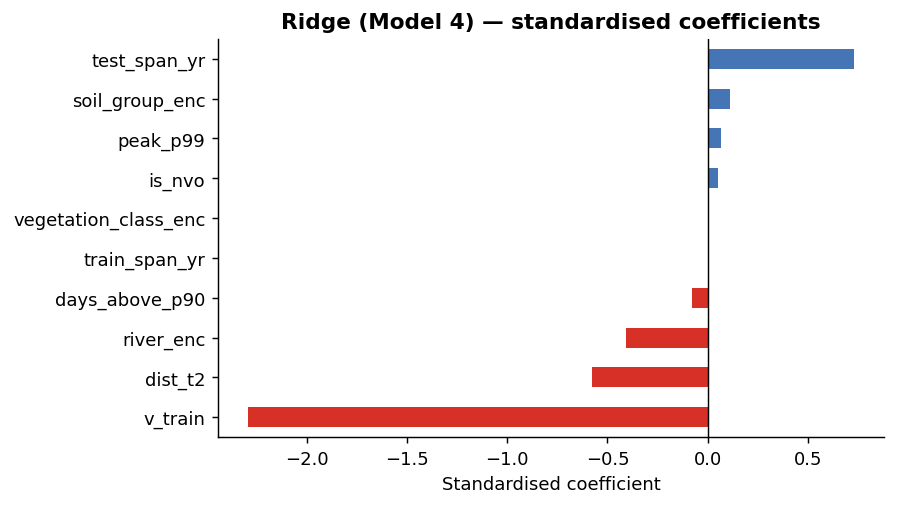

In [12]:
coef_series = pd.Series(
    ridge_cat.named_steps["ridge"].coef_, index=FEATS_4
).sort_values()

colors_coef = ["#d73027" if c < 0 else "#4575b4" for c in coef_series]
fig, ax = plt.subplots(figsize=(7, 4))
coef_series.plot.barh(ax=ax, color=colors_coef)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardised coefficient")
ax.set_title("Ridge (Model 4) — standardised coefficients", fontweight="bold")
plt.tight_layout(); plt.show()


## Per-river RMSE breakdown — best model (LightGBM)
Checks whether the model generalises equally well across all river segments.

,v_train baseline,LightGBM
river,,
ijssel1,1.7713,1.3755
ijssel2,2.7012,1.6332
maas1,0.8136,2.6356
maas2,8.7807,6.4399
maas3,3.9102,2.3020
nederrijn,5.3899,3.3844
rijn,13.0010,2.3799


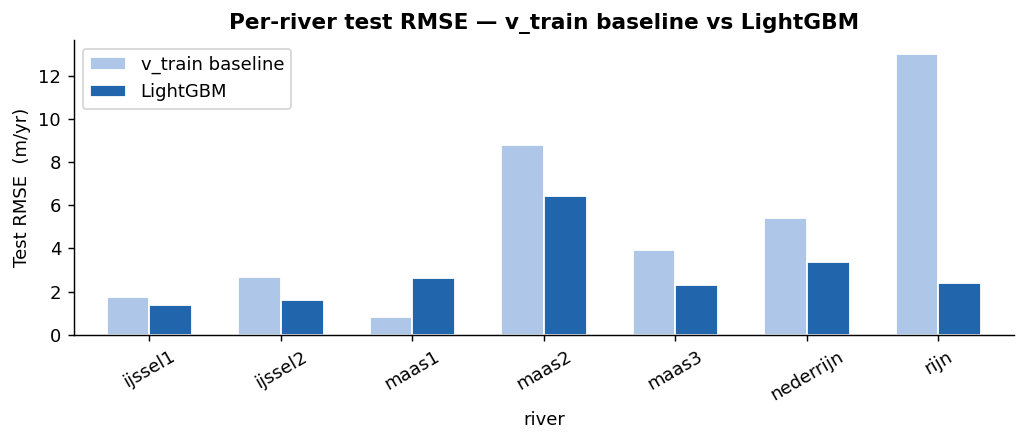

In [13]:
test_copy = test.copy()
test_copy["pred_lgb"]      = y_te_lgb
test_copy["pred_baseline"] = test_copy["v_train"]


def river_rmse(df, pred_col):
    return (df.groupby("river")
              .apply(lambda g: root_mean_squared_error(g[TARGET], g[pred_col]),
                     include_groups=False)
              .rename(pred_col))


river_df = pd.concat([
    river_rmse(test_copy, "pred_baseline"),
    river_rmse(test_copy, "pred_lgb"),
], axis=1)
river_df.columns = ["v_train baseline", "LightGBM"]

display(river_df.round(4))

ax = river_df.plot.bar(figsize=(8, 3.5), width=0.65, edgecolor="white",
                       color=["#aec6e8", "#2166ac"])
ax.set_ylabel("Test RMSE  (m/yr)")
ax.set_title("Per-river test RMSE — v_train baseline vs LightGBM", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


## Takeaways

*Fill in after running the notebook.*

- Does adding categorical features (river, soil, NVO) improve over pure-numeric Ridge?
- Does LightGBM beat Ridge, suggesting meaningful non-linearities?
- Which features have the highest SHAP gain?
- Are there specific rivers where the model still struggles?
